<a href="https://jupyterhub.user.eopf.eodc.eu/hub/user-redirect/git-pull?repo=https://github.com/eopf-toolkit/eopf-101&branch=main&urlpath=lab/tree/eopf-101/06_eopf_zarr_in_action/611_intertidal_vegetation_monitoring_with_s2.ipynb" target="_blank">
  <button style="background-color:#0072ce; color:white; padding:0.6em 1.2em; font-size:1rem; border:none; border-radius:6px; margin-top:1em;">
    🚀 Launch this notebook in JupyterLab
  </button>
</a>

**By:** *[@fer-at-sea](https://github.com/fer-at-sea)* and *[@pglez82](https://github.com/pglez82)*

### Introduction

**Intertidal zones** — the strip of coastline exposed at low tide and submerged at high tide — are among the most productive and ecologically significant habitats on Earth. Despite covering less than 0.5 % of the global ocean surface, they provide key ecosystem services:

- **Carbon sequestration**: Salt marshes and seagrass meadows are “blue carbon” ecosystems that can sequester carbon at rates several times higher than terrestrial forests and store much of it in long-term sediments.
- **Coastal protection**: Intertidal vegetation dissipates wave energy, reducing flood risk for coastal communities in a warming climate.
- **Biodiversity hotspots**: These zones support invertebrates, migratory shorebirds, juvenile fish, and endemic plant communities that exist nowhere else.
- **Climate sensitivity**: Because intertidal vegetation is simultaneously exposed to the atmosphere (temperature, drought) and the sea (salinity, sea-level change), it acts as an early-warning indicator of climate-driven coastal stress.


### Study Area

**The Villaviciosa estuary** (Asturias, northern Spain) is a Ramsar-designated wetland of international importance hosting extensive intertidal mudflats and saltmarshes. Regular and systematic monitoring at fine spatial scales can provide valuable information on habitat dynamics but is often difficult to sustain using field surveys alone. Satellite remote sensing, particularly within cloud-native processing frameworks, offers a complementary approach that can facilitate basin-scale and time-series monitoring.


Key characteristics relevant to our remote-sensing approach:

| Feature | Detail |
|---|---|
| **Tidal regime** | Semi-diurnal; tidal range ~4 m at spring tides |
| **Exposures** | Extensive low-gradient mudflats exposed for 6–8 h per tidal cycle |
| **Designations** | Ramsar site, Natura 2000 SAC/SPA, Asturias Nature Reserve |
| **Sentinel-2 tiles** | Primarily 29TQJ / 30TUP (border zone between UTM zones 29N and 30N) |

A semi-diurnal tidal regime with ~4 m range means that at any given Sentinel-2 overpass (roughly every 5 days), the estuary may be near fully exposed, near fully submerged, or anywhere in between. This tidal variability is the **key driver** of the water-frequency approach: rather than attempting to record a single synoptic state, we accumulate many snapshots across the full tidal cycle and use the *fraction* of time a pixel is wet as a proxy for intertidal zone extent.

<hr>

### What we will learn
- 🛰️ How to discover Sentinel-2 products via EOPF STAC and open them as Zarr with xarray.
- 🌊 How to build a time series over a coastal area using lazy loading and partial reads (cloud-native workflow).
- 🌿 How to derive simple spectral indicators to support intertidal vegetation monitoring and visualise the results.


### Prerequisites

#### Workflow Overview

We build a complete cloud-native workflow in six stages:

1. **Data discovery** — query the EOPF STAC catalogue for Sentinel-2 L2A tiles covering the study area using `pystac_client`, with no data download required.
2. **Lazy cloud access** — open each tile as a Dask-backed `xarray` dataset directly from object storage via the `eopf-zarr` engine and clip it to the area of interest.
3. **Water frequency mapping** — stack the Scene Classification Layer (SCL) across all acquisitions to compute a per-pixel water frequency, exploiting the tidal cycle as a natural inundation signal.
4. **Intertidal zone delineation** — threshold the water frequency map to isolate intermittently flooded pixels and export the result as a GeoTIFF and GeoPackage vector file.
5. **Vegetation monitoring** — for each cloud-free acquisition, compute the Normalised Difference Vegetation Index (NDVI) from the red (B04) and near-infrared (B08) bands, restrict the analysis to exposed intertidal pixels (SCL 4/5), and track the fraction with NDVI > 0.2 over time. Normalising by the number of exposed pixels rather than total intertidal area removes the tidal confounding effect, giving a tide-independent vegetation cover metric.
6. **Temporal aggregation** — summarise the NDVI time series by calendar month and by season (Winter / Spring / Summer / Autumn) to reveal phenological patterns in intertidal vegetation cover.

> **A note on data availability**
> The [EOPF Zarr Sample Service STAC catalogue](https://stac.core.eopf.eodc.eu) maintains a **rolling archive of ~1 year for Europe**. This has two important implications for this workflow:
>
> - **Intertidal mask quality** improves with more images. A longer time series captures a wider range of tidal states — including extreme high and low tides — which helps the water-frequency approach converge on the true intertidal boundary. With only a year of data the mask may be incomplete or biased towards the tidal conditions that happened to be observed.
> - **NDVI temporal trend** becomes more meaningful as the archive grows. Seasonal vegetation cycles (e.g. growth of seagrass or macroalgal blooms) can only be detected once multi-month records are available. As the rolling window advances, re-running this notebook will automatically incorporate new acquisitions.


#### Import libraries

In [1]:
# Standard library
from concurrent.futures import ThreadPoolExecutor, as_completed

# Scientific computing
import numpy as np
import pandas as pd

# Geospatial 
import rasterio
import rasterio.enums
import rasterio.transform
from rasterio.features import shapes
from rasterio.warp import reproject as rio_reproject, Resampling, calculate_default_transform
import rioxarray  # noqa: F401  – required to activate the .rio accessor on xarray objects
import xarray as xr
import geopandas as gpd
from shapely.geometry import box, shape
from pyproj import Transformer
from pyproj import CRS

# Visualisation
import matplotlib.pyplot as plt
import contextily as ctx

# EO data access
import pystac_client


<hr>

### Area of interest

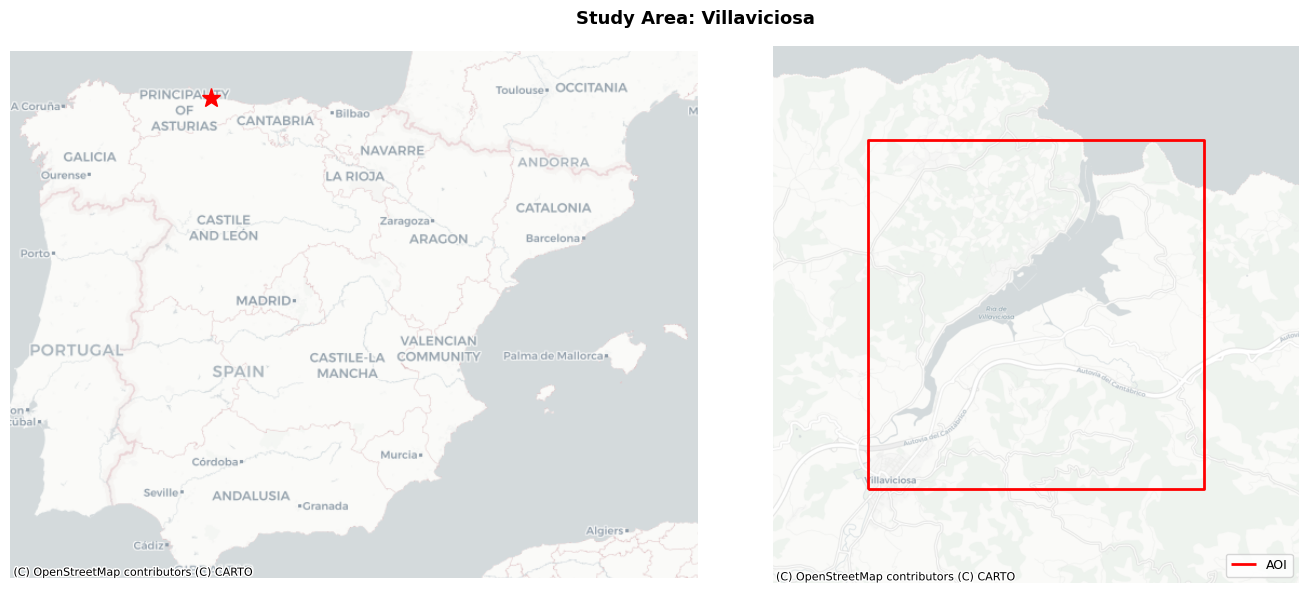

In [2]:
site = "Villaviciosa"
bbox = [-5.44, 43.48, -5.36, 43.54]
crs_wgs84 = "EPSG:4326"
crs_web_mercator = "EPSG:3857"


# -----------------------------
# STUDY AREA MAP
# -----------------------------
aoi_wm = gpd.GeoDataFrame(geometry=[box(*bbox)], crs=crs_wgs84).to_crs(crs_web_mercator)

fig, (ax_ov, ax_det) = plt.subplots(1, 2, figsize=(14, 6))

# ---- Left ----
spain_wm = gpd.GeoDataFrame(
    geometry=[box(-9.5, 36.0, 4.5, 44.2)], crs=crs_wgs84
).to_crs(crs_web_mercator)
b = spain_wm.total_bounds
ax_ov.set_xlim(b[0], b[2])
ax_ov.set_ylim(b[1], b[3])
ctx.add_basemap(ax_ov, crs=crs_web_mercator, source=ctx.providers.CartoDB.Positron, zoom=6)
aoi_wm.boundary.plot(ax=ax_ov, color="red", linewidth=1.5)
centroid = aoi_wm.geometry.iloc[0].centroid
ax_ov.plot(centroid.x, centroid.y, marker="*", color="red", markersize=14, zorder=5)
ax_ov.set_axis_off()

# ---- Right ----
BUFFER = 2500   
b = aoi_wm.total_bounds
ax_det.set_xlim(b[0] - BUFFER, b[2] + BUFFER)
ax_det.set_ylim(b[1] - BUFFER, b[3] + BUFFER)
ctx.add_basemap(ax_det, crs=crs_web_mercator, source=ctx.providers.CartoDB.Positron, zoom=13)
aoi_wm.boundary.plot(ax=ax_det, color="red", linewidth=2, label="AOI")
ax_det.legend(loc="lower right", fontsize=9)
ax_det.set_axis_off()

fig.suptitle(f"Study Area: {site}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Fetching S2 L2A zarr data

### STAC API Search

#### What is STAC?

The **SpatioTemporal Asset Catalog (STAC)** specification is an open standard that describes geospatial datasets as machine-readable JSON "Items". Each Item carries metadata (bounding box, acquisition time, cloud cover, CRS, sensor mode) and a set of `assets` — direct links to the actual data files on cloud storage. A STAC catalogue therefore acts as a lightweight, queryable index over a potentially huge archive, without requiring you to download or even inspect any imagery upfront.

The [EOPF Zarr Sample Service STAC endpoint](https://stac.core.eopf.eodc.eu) exposes the rolling ~1-year archive of Sentinel-2 L1C and L2A products repackaged as Zarr stores. We use it with `pystac_client`.

#### Pre-filtering strategy

We apply a generous `eo:cloud_cover < 80 %` threshold here — this discards heavily overcast scenes at catalogue level, avoiding unnecessary Zarr open calls. A **stricter, pixel-level cloud check** (SCL cloud classes over the intertidal zone only) is applied later in the NDVI cell, where we can afford to be more precise because we are already working with clipped sub-tiles.

We query the [EOPF STAC catalogue](https://stac.core.eopf.eodc.eu) for `sentinel-2-l2a` items that intersect our bounding box. The `pystac_client` library handles pagination automatically, returning a list of `Item` objects each pointing to a Zarr store on cloud object storage.


In [3]:

# -----------------------------
# PARAMETERS
# -----------------------------
time_range      = ["2025-05-01", "2026-03-31"]  # query from this date to the latest available, no previous images are currently available
cloud_cover_max = 80                    # pre-filter: discard scenes with >80% scene-wide cloud cover
                                        # (a stricter per-zone cloud check is applied later in the NDVI cell)

# -----------------------------
# STAC CATALOGUE SEARCH
# -----------------------------

catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")

items = list(
    catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime=time_range,
        query={"eo:cloud_cover": {"lt": cloud_cover_max}},
    ).items()
)

print(f"Items found: {len(items)}  (cloud cover < {cloud_cover_max}%)")
for item in items:
    cc = item.properties.get("eo:cloud_cover", "?")
    print(f"  {item.datetime.strftime('%Y-%m-%d')}  |  {item.properties['proj:code']}  |  cloud {cc}%")


/Users/giselaromerocandanedo/Documents/thriveGEO_eopf/cloned_rep/eopf-101/.venv/lib/python3.12/site-packages/pystac/item.py:483: DeprecatedWarning: The item 'S2B_MSIL2A_20251101T111119_N0511_R137_T29TQJ_20251101T135730' is deprecated.
  warnings.warn(


Items found: 119  (cloud cover < 80%)
  2026-03-31  |  EPSG:32630  |  cloud 79.016393%
  2026-03-29  |  EPSG:32630  |  cloud 53.722095%
  2026-03-29  |  EPSG:32629  |  cloud 61.170441%
  2026-03-24  |  EPSG:32630  |  cloud 12.640411%
  2026-03-24  |  EPSG:32629  |  cloud 15.504809%
  2026-03-21  |  EPSG:32630  |  cloud 23.101231%
  2026-03-21  |  EPSG:32629  |  cloud 16.229358%
  2026-03-21  |  EPSG:32630  |  cloud 21.666494%
  2026-03-21  |  EPSG:32629  |  cloud 24.121855%
  2026-03-19  |  EPSG:32630  |  cloud 20.799819%
  2026-03-19  |  EPSG:32629  |  cloud 41.830054%
  2026-03-18  |  EPSG:32630  |  cloud 53.902984%
  2026-03-18  |  EPSG:32629  |  cloud 65.02555%
  2026-03-16  |  EPSG:32630  |  cloud 51.24855%
  2026-03-16  |  EPSG:32629  |  cloud 40.440392%
  2026-03-11  |  EPSG:32629  |  cloud 79.928911%
  2026-03-08  |  EPSG:32630  |  cloud 63.699955%
  2026-03-08  |  EPSG:32629  |  cloud 20.919046%
  2026-03-04  |  EPSG:32630  |  cloud 28.654%
  2026-03-04  |  EPSG:32629  |  clou

In [4]:
# Print total number of items found
print(f"Total items found: {len(items)}")
print("-------------------------------")


# Inspect the first STAC item — key metadata and the product asset URL
print("First item metadata:")
item = items[0]

print(f"Item ID   : {item.id}")
print(f"Date      : {item.datetime.strftime('%Y-%m-%d %H:%M UTC')}")
print(f"Cloud cover: {item.properties.get('eo:cloud_cover', 'N/A')} %")
print(f"CRS       : {item.properties.get('proj:code', 'N/A')}")
print(f"Product URL: {item.assets['product'].href}")


Total items found: 119
-------------------------------
First item metadata:
Item ID   : S2A_MSIL2A_20260331T112131_N0512_R037_T30TUP_20260331T200509
Date      : 2026-03-31 11:21 UTC
Cloud cover: 79.016393 %
CRS       : EPSG:32630
Product URL: https://objects.eodc.eu:443/e05ab01a9d56408d82ac32d69a5aae2a:202603-s02msil2a-eu/31/products/cpm_v270/S2A_MSIL2A_20260331T112131_N0512_R037_T30TUP_20260331T200509.zarr


### Load into xarray

#### Why `eopf-zarr` + Dask?

Traditional EO workflows require downloading full granules (often hundreds of MB per scene) before any analysis. The `eopf-zarr` xarray engine replaces that pattern with **streaming access**: data is read in small HTTP range-requests from the object store only when a computation actually requires it. Wrapping the dataset with Dask (`chunks={}`) defers even those reads until explicitly triggered — the cell below executes relatively fast, because it only fetches metadata and coordinates.

Key concepts:
- **`xr.open_dataset(..., engine="eopf-zarr", chunks={})`** — opens the store lazily; all variable arrays are Dask graphs, not in-memory arrays.
- **`.sel(x=..., y=...)`** — label-based slicing restricts subsequent reads to the AOI bounding box; pixels outside the window are never fetched.
- **CRS alignment** — the study area straddles the UTM 29N / 30N tile boundary, so we reproject the WGS-84 bounding box into each tile's native CRS before slicing.

For each STAC item we open the corresponding Zarr store with the `eopf-zarr` engine — **no file download required**. We then clip each dataset to the AOI using `xarray` label-based indexing and skip any item that has no overlap or is missing a CRS. Dask chunks (`chunks={}`) ensure that data is read lazily and only the pixels within the AOI are actually loaded into memory.

> **Sequential vs. parallel loading**: The notebook provides **two alternative cells** — a simple sequential loop (easy to follow) and a concurrent version using `ThreadPoolExecutor`. The parallel version issues all Zarr metadata requests simultaneously, dramatically reducing wall-clock time when the archive contains many items. The outputs of both cells are identical; only one needs to be run.


In [5]:
# datasets, included_items, skipped, crs_list = [], [], [], []

# for item in items:
#     url = item.assets["product"].href

#     # --- Try to open dataset ---
#     try:
#         ds = xr.open_dataset(url, engine="eopf-zarr", chunks={})
#     except Exception as e:
#         print(f"\n-{e}")
#         skipped.append(url)
#         continue

#     # --- Get CRS ---
#     crs = ds.rio.crs
#     print(f"\n-{url.split('/')[-1]}")
#     print(f"   CRS: {crs}")

#     if crs is None:
#         print("   No CRS found, skipping")
#         skipped.append(url)
#         continue

#     # --- Reproject WGS84 bbox to dataset CRS ---
#     transformer = Transformer.from_crs("EPSG:4326", crs, always_xy=True)
#     minx, miny = transformer.transform(bbox[0], bbox[1])
#     maxx, maxy = transformer.transform(bbox[2], bbox[3])

#     # --- Handle Y axis direction ---
#     y_slice = slice(maxy, miny) if ds.y[0] > ds.y[-1] else slice(miny, maxy)

#     # --- Clip ---
#     ds_clipped = ds.sel(x=slice(minx, maxx), y=y_slice)

#     if ds_clipped.sizes["x"] == 0 or ds_clipped.sizes["y"] == 0:
#         print("   No overlap with bbox after reprojection")
#         skipped.append(url)
#         continue

#     print(f"   Clipped size: {dict(ds_clipped.sizes)}")

#     # --- Store dataset and its STAC item together ---
#     datasets.append(ds_clipped)
#     included_items.append(item)
#     crs_list.append(crs)

# print(f"\n✓ Included: {len(included_items)} | ✗ Skipped: {len(skipped)}")


The following cell is a Parallel version of the cell above, aiming to run all Zarr items concurrently. The results are sorted by acquisition date so downstream cells are unaffected.

In [6]:
MAX_WORKERS = 8   # concurrent metadata fetches; tune to network conditions

# Transformer cache: avoids rebuilding the same CRS projection per thread.
# NW Spain tiles appear in both EPSG:32629 (Zone 29N) and EPSG:32630 (Zone 30N).
_transformer_cache: dict = {}

def _open_and_clip(item):
    """Open the Zarr store as a DataTree, extract & merge groups, and clip to bbox."""
    url = item.assets["product"].href
    msgs = [f"\n- {url.split('/')[-1]}"]

    try:
        dt = xr.open_datatree(url, engine="eopf-zarr", chunks={})
        
        # Extract the two groups using simple path-based indexing
        ds_ref = dt["measurements/reflectance/r20m"].to_dataset()
        ds_mask = dt["conditions/mask/l2a_classification/r20m"].to_dataset()
        ds = xr.merge([ds_ref, ds_mask])
        
    except Exception as e:
        msgs.append(f"   ERROR opening DataTree or merging groups: {e}")
        return None, item, None, msgs
    
    # Extract CRS from your known metadata path (inherited from the root)
    raw_crs = dt.attrs.get('stac_discovery', {}).get('properties', {}).get('proj:code')
    
    if not raw_crs:
        msgs.append("   No CRS string found in metadata, skipping")
        return None, item, None, msgs

    try:
        crs = CRS.from_user_input(raw_crs)
        ds.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=True)
        ds = ds.rio.write_crs(crs)
        
    except Exception as crs_err:
        msgs.append(f"   Failed to assign CRS to merged dataset: {crs_err}")
        return None, item, None, msgs

    msgs.append(f"   CRS: {crs}")

    # Reuse transformer if the same CRS was seen before
    crs_key = str(crs)
    if crs_key not in _transformer_cache:
        _transformer_cache[crs_key] = Transformer.from_crs("EPSG:4326", crs, always_xy=True)
    transformer = _transformer_cache[crs_key]

    minx, miny = transformer.transform(bbox[0], bbox[1])
    maxx, maxy = transformer.transform(bbox[2], bbox[3])
    
    # Slice both groups simultaneously
    y_slice = slice(maxy, miny) if ds.y[0] > ds.y[-1] else slice(miny, maxy)
    ds_clipped = ds.sel(x=slice(minx, maxx), y=y_slice)

    if ds_clipped.sizes["x"] == 0 or ds_clipped.sizes["y"] == 0:
        msgs.append("   No overlap with bbox after reprojection")
        return None, item, None, msgs

    msgs.append(f"   Clipped size (includes bands & mask): {dict(ds_clipped.sizes)}")
    return ds_clipped, item, crs, msgs

# Set variables to store results 

datasets, included_items, skipped, crs_list = [], [], [], []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
    future_to_item = {pool.submit(_open_and_clip, item): item for item in items}
    raw_results = []
    for future in as_completed(future_to_item):
        ds_clipped, item, crs, msgs = future.result()
        for m in msgs:
            print(m)
        raw_results.append((item.datetime, ds_clipped, item, crs))

# Sort chronologically — as_completed returns in arrival order, not submission order
raw_results.sort(key=lambda r: r[0])

for _, ds_clipped, item, crs in raw_results:
    if ds_clipped is not None:
        datasets.append(ds_clipped)
        included_items.append(item)
        crs_list.append(crs)
    else:
        skipped.append(item.assets["product"].href)

print(f"\n✓ Included: {len(included_items)} | ✗ Skipped: {len(skipped)}")

/Users/giselaromerocandanedo/Documents/thriveGEO_eopf/cloned_rep/eopf-101/.venv/lib/python3.12/site-packages/xarray_sentinel/esa_safe.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/giselaromerocandanedo/Documents/thriveGEO_eopf/cloned_rep/eopf-101/.venv/lib/python3.12/site-packages/zarr/core/group.py:579: ZarrUserWarning: Both zarr.json (Zarr format 3) and .zgroup (Zarr format 2) metadata objects exist at <FsspecStore(HTTPFileSystem, https://data.eodc.eu/collections/EOPF_ZARR/products/cpm_v270/S02MSIL2A/2026/03/21/S2A_MSIL2A_20260321T112131_N0512_R037_T29TQJ_20260321T200016.zarr)>. Zarr format 3 will be used.
  warnings.warn(msg, category=ZarrUserWarning, stacklevel=1)
/Users/giselaromerocandanedo/Documents/thriveGEO_eopf/cloned_rep/eopf-101/.venv/lib/python3


- S2A_MSIL2A_20260321T112131_N0512_R037_T29TQJ_20260321T200016.zarr
   ERROR opening DataTree or merging groups: Expecting value: line 1 column 1 (char 0)


/Users/giselaromerocandanedo/Documents/thriveGEO_eopf/cloned_rep/eopf-101/.venv/lib/python3.12/site-packages/xarray_eopf/amodes/sentinel2.py:145: UserWarning: Analysis mode not implemented for given source, return data tree as-is.
  warnings.warn(
/Users/giselaromerocandanedo/Documents/thriveGEO_eopf/cloned_rep/eopf-101/.venv/lib/python3.12/site-packages/xarray_eopf/amodes/sentinel2.py:145: UserWarning: Analysis mode not implemented for given source, return data tree as-is.
  warnings.warn(
/Users/giselaromerocandanedo/Documents/thriveGEO_eopf/cloned_rep/eopf-101/.venv/lib/python3.12/site-packages/xarray_eopf/amodes/sentinel2.py:145: UserWarning: Analysis mode not implemented for given source, return data tree as-is.
  warnings.warn(



- S2A_MSIL2A_20260331T112131_N0512_R037_T30TUP_20260331T200509.zarr
   CRS: EPSG:32630
   Clipped size (includes bands & mask): {'y': 323, 'x': 333}

- S2B_MSIL2A_20260321T110649_N0512_R137_T30TUP_20260321T134453.zarr
   CRS: EPSG:32630
   Clipped size (includes bands & mask): {'y': 323, 'x': 333}

- S2B_MSIL2A_20260324T112109_N0512_R037_T29TQJ_20260324T150715.zarr
   CRS: EPSG:32629
   Clipped size (includes bands & mask): {'y': 347, 'x': 308}

- S2B_MSIL2A_20260324T112109_N0512_R037_T30TUP_20260324T150715.zarr
   CRS: EPSG:32630
   Clipped size (includes bands & mask): {'y': 323, 'x': 333}

- S2C_MSIL2A_20260329T112111_N0512_R037_T30TUP_20260329T144222.zarr
   CRS: EPSG:32630
   Clipped size (includes bands & mask): {'y': 323, 'x': 333}

- S2B_MSIL2A_20260321T110649_N0512_R137_T29TQJ_20260321T134453.zarr
   CRS: EPSG:32629
   Clipped size (includes bands & mask): {'y': 347, 'x': 308}

- S2C_MSIL2A_20260329T112111_N0512_R037_T29TQJ_20260329T144222.zarr
   CRS: EPSG:32629
   Clipped s

/Users/giselaromerocandanedo/Documents/thriveGEO_eopf/cloned_rep/eopf-101/.venv/lib/python3.12/site-packages/xarray_eopf/amodes/sentinel2.py:145: UserWarning: Analysis mode not implemented for given source, return data tree as-is.
  warnings.warn(
/Users/giselaromerocandanedo/Documents/thriveGEO_eopf/cloned_rep/eopf-101/.venv/lib/python3.12/site-packages/xarray_eopf/amodes/sentinel2.py:145: UserWarning: Analysis mode not implemented for given source, return data tree as-is.
  warnings.warn(
/Users/giselaromerocandanedo/Documents/thriveGEO_eopf/cloned_rep/eopf-101/.venv/lib/python3.12/site-packages/xarray_eopf/amodes/sentinel2.py:145: UserWarning: Analysis mode not implemented for given source, return data tree as-is.
  warnings.warn(
/Users/giselaromerocandanedo/Documents/thriveGEO_eopf/cloned_rep/eopf-101/.venv/lib/python3.12/site-packages/xarray_eopf/amodes/sentinel2.py:145: UserWarning: Analysis mode not implemented for given source, return data tree as-is.
  warnings.warn(
/Users/g

...


- S2C_MSIL2A_20250523T112131_N0511_R037_T30TUP_20250523T134256.zarr
   CRS: EPSG:32630
   Clipped size (includes bands & mask): {'y': 323, 'x': 333}

- S2B_MSIL2A_20250525T110619_N0511_R137_T29TQJ_20250525T133604.zarr
   CRS: EPSG:32629
   Clipped size (includes bands & mask): {'y': 347, 'x': 308}

- S2C_MSIL2A_20250523T112131_N0511_R037_T29TQJ_20250523T134256.zarr
   CRS: EPSG:32629
   Clipped size (includes bands & mask): {'y': 347, 'x': 308}

- S2B_MSIL2A_20250518T112119_N0511_R037_T30TUP_20250518T133728.zarr
   CRS: EPSG:32630
   Clipped size (includes bands & mask): {'y': 323, 'x': 333}

- S2A_MSIL2A_20250522T110711_N0511_R137_T30TUP_20250522T150814.zarr
   CRS: EPSG:32630
   Clipped size (includes bands & mask): {'y': 323, 'x': 333}

- S2B_MSIL2A_20250518T112119_N0511_R037_T29TQJ_20250518T133728.zarr
   CRS: EPSG:32629
   Clipped size (includes bands & mask): {'y': 347, 'x': 308}


/Users/giselaromerocandanedo/Documents/thriveGEO_eopf/cloned_rep/eopf-101/.venv/lib/python3.12/site-packages/xarray_eopf/amodes/sentinel2.py:145: UserWarning: Analysis mode not implemented for given source, return data tree as-is.
  warnings.warn(
/Users/giselaromerocandanedo/Documents/thriveGEO_eopf/cloned_rep/eopf-101/.venv/lib/python3.12/site-packages/xarray_eopf/amodes/sentinel2.py:145: UserWarning: Analysis mode not implemented for given source, return data tree as-is.
  warnings.warn(
/Users/giselaromerocandanedo/Documents/thriveGEO_eopf/cloned_rep/eopf-101/.venv/lib/python3.12/site-packages/xarray_eopf/amodes/sentinel2.py:145: UserWarning: Analysis mode not implemented for given source, return data tree as-is.
  warnings.warn(
/Users/giselaromerocandanedo/Documents/thriveGEO_eopf/cloned_rep/eopf-101/.venv/lib/python3.12/site-packages/xarray_eopf/amodes/sentinel2.py:145: UserWarning: Analysis mode not implemented for given source, return data tree as-is.
  warnings.warn(
/Users/g


- S2C_MSIL2A_20250513T112131_N0511_R037_T30TUP_20250513T135636.zarr
   CRS: EPSG:32630
   Clipped size (includes bands & mask): {'y': 323, 'x': 333}

- S2C_MSIL2A_20250510T110641_N0511_R137_T29TQJ_20250510T182913.zarr
   CRS: EPSG:32629
   Clipped size (includes bands & mask): {'y': 347, 'x': 308}

- S2C_MSIL2A_20250513T112131_N0511_R037_T29TQJ_20250513T135636.zarr
   CRS: EPSG:32629
   Clipped size (includes bands & mask): {'y': 347, 'x': 308}

- S2B_MSIL2A_20250508T112119_N0511_R037_T30TUP_20250508T133101.zarr
   CRS: EPSG:32630
   Clipped size (includes bands & mask): {'y': 323, 'x': 333}

- S2A_MSIL2A_20250505T112131_N0511_R037_T30TUP_20250506T030002.zarr
   CRS: EPSG:32630
   Clipped size (includes bands & mask): {'y': 323, 'x': 333}

- S2B_MSIL2A_20250505T110619_N0511_R137_T29TQJ_20250505T134959.zarr
   CRS: EPSG:32629
   Clipped size (includes bands & mask): {'y': 347, 'x': 308}


/Users/giselaromerocandanedo/Documents/thriveGEO_eopf/cloned_rep/eopf-101/.venv/lib/python3.12/site-packages/xarray_eopf/amodes/sentinel2.py:145: UserWarning: Analysis mode not implemented for given source, return data tree as-is.
  warnings.warn(
/Users/giselaromerocandanedo/Documents/thriveGEO_eopf/cloned_rep/eopf-101/.venv/lib/python3.12/site-packages/xarray_eopf/amodes/sentinel2.py:145: UserWarning: Analysis mode not implemented for given source, return data tree as-is.
  warnings.warn(



- S2C_MSIL2A_20250503T112131_N0511_R037_T30TUP_20250503T165214.zarr
   CRS: EPSG:32630
   Clipped size (includes bands & mask): {'y': 323, 'x': 333}

- S2A_MSIL2A_20260321T112131_N0512_R037_T30TUP_20260321T200016.zarr
   ERROR opening DataTree or merging groups: 504, message='Gateway Time-out', url='https://data.eodc.eu/collections/EOPF_ZARR/products/cpm_v270/S02MSIL2A/2026/03/21/S2A_MSIL2A_20260321T112131_N0512_R037_T30TUP_20260321T200016.zarr/.zattrs'

- S2A_MSIL2A_20260318T110731_N0512_R137_T30TUP_20260318T180922.zarr
   ERROR opening DataTree or merging groups: 504, message='Gateway Time-out', url='https://data.eodc.eu/collections/EOPF_ZARR/products/cpm_v270/S02MSIL2A/2026/03/18/S2A_MSIL2A_20260318T110731_N0512_R137_T30TUP_20260318T180922.zarr/zarr.json'

✓ Included: 97 | ✗ Skipped: 22


## Intertidal zone calculation

### Water Frequencies

#### The Scene Classification Layer (SCL)

Every Sentinel-2 L2A product includes a **Scene Classification Layer (SCL)** — a 20-m resolution per-pixel quality and land-cover flag generated by the Sen2Cor atmospheric correction processor. It assigns each pixel one of 12 classes:

| SCL value | Meaning |
|---|---|
| 0 | No data |
| 1 | Saturated / defective |
| 2 | Dark area pixels |
| 3 | Cloud shadows |
| 4 | **Vegetation** |
| 5 | **Not-vegetated (bare soil/sand)** |
| 6 | **Water** |
| 7 | Unclassified |
| 8 | Cloud (medium probability) |
| 9 | Cloud (high probability) |
| 10 | Thin cirrus |
| 11 | Snow / ice |

We focus on classes **4, 5, and 6** (valid clear-sky observations) and use class **6** as the water signal. Other classes indicate cloud, shadow, or sensor issues and are excluded.

#### Why water frequency reveals the intertidal zone

At any given satellite overpass the estuary is in a particular tidal state: fully exposed, fully submerged, or partially inundated. No single image shows the complete intertidal boundary. However, **over many acquisitions that span the full tidal cycle**, each pixel accumulates enough observations to estimate the fraction of clear-sky time it spent under water:

$$\text{water\_frequency}(x, y) = \frac{\sum_t \mathbf{1}[\text{SCL}_{t}(x,y) = 6]}{\sum_t \mathbf{1}[\text{SCL}_{t}(x,y) \in \{4, 5, 6\}]}$$

- **Values ≈ 0** → permanently dry land (above high-tide line)
- **Values ≈ 1** → permanently submerged (below low-tide line)
- **Intermediate values (0.1 – 0.95)** → intermittently inundated pixels, i.e., the **intertidal zone**

This approach requires no tidal model, no DEM, and no field calibration: the tidal signal is encoded in the archive itself.

> **Grid alignment**: Because different tiles may be projected in different UTM zones (29N or 30N), we reproject every SCL array onto a common reference grid (`datasets[0]`) using nearest-neighbour resampling before accumulating counts. This ensures the pixel-wise sums are geographically consistent.


In [7]:
datasets

[<xarray.Dataset> Size: 9MB
 Dimensions:      (y: 323, x: 333)
 Coordinates:
   * y            (y) float32 1kB 4.823e+06 4.823e+06 ... 4.817e+06 4.817e+06
   * x            (x) float32 1kB 3.027e+05 3.027e+05 ... 3.093e+05 3.093e+05
     spatial_ref  int64 8B 0
 Data variables:
     b01          (y, x) float64 860kB dask.array<chunksize=(323, 333), meta=np.ndarray>
     b02          (y, x) float64 860kB dask.array<chunksize=(323, 333), meta=np.ndarray>
     b03          (y, x) float64 860kB dask.array<chunksize=(323, 333), meta=np.ndarray>
     b04          (y, x) float64 860kB dask.array<chunksize=(323, 333), meta=np.ndarray>
     b05          (y, x) float64 860kB dask.array<chunksize=(323, 333), meta=np.ndarray>
     b06          (y, x) float64 860kB dask.array<chunksize=(323, 333), meta=np.ndarray>
     b07          (y, x) float64 860kB dask.array<chunksize=(323, 333), meta=np.ndarray>
     b11          (y, x) float64 860kB dask.array<chunksize=(323, 333), meta=np.ndarray>
     b12 

Water frequency map saved: outputs/water_frequency.tif


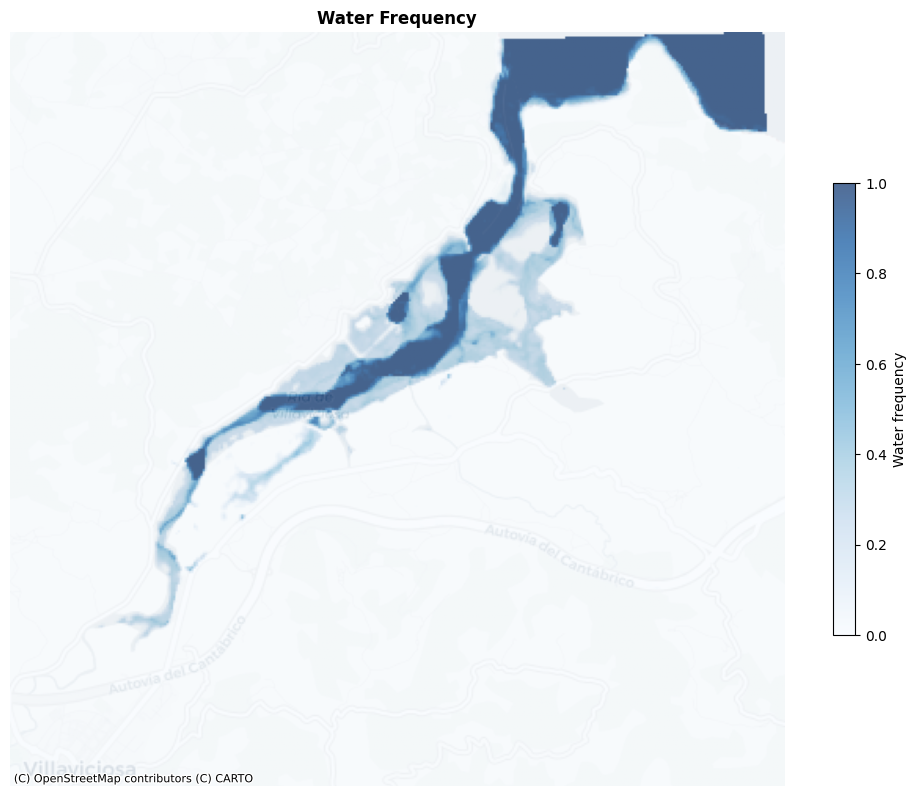

In [8]:
# -----------------------------
# PARAMETERS
# -----------------------------
# Pick a reference dataset for alignment
ref_ds = datasets[0]['scl']

# Reference CRS, transform, and shape
target_crs = ref_ds.rio.crs
ny, nx = ref_ds.sizes['y'], ref_ds.sizes['x']

# Initialize accumulators
water_count = np.zeros((ny, nx), dtype=int)
obs_count = np.zeros((ny, nx), dtype=int)

# -----------------------------
# LOOP OVER DATASETS
# -----------------------------
for ds in datasets:
    if 'scl' not in ds:
        continue

    scl = ds['scl']

    # Flip Y if descending
    if scl.y[0] > scl.y[-1]:
        scl = scl.isel(y=slice(None, None, -1))

    # Ensure CRS is set
    if scl.rio.crs is None:
        scl = scl.rio.write_crs(target_crs, inplace=True)

    # Reproject to reference dataset grid
    scl_rp = scl.rio.reproject_match(
        ref_ds,
        resampling=rasterio.enums.Resampling.nearest
    )

    # Convert to numpy
    scl_vals = scl_rp.values

    # Valid pixels and water mask
    valid = np.isin(scl_vals, [4, 5, 6])  # only clear land or water
    water = (scl_vals == 6)

    # Accumulate counts
    obs_count[valid] += 1
    water_count[valid] += water[valid]

# -----------------------------
# COMPUTE WATER FREQUENCY
# -----------------------------
freq = np.full_like(water_count, fill_value=np.nan, dtype=float)
mask = obs_count > 0
freq[mask] = water_count[mask] / obs_count[mask]

# -----------------------------
# SAVE AS GEO-TIFF
# -----------------------------
out_path = "outputs/water_frequency.tif"

# with rasterio.open(
#     out_path,
#     'w',
#     driver='GTiff',
#     height=ny,
#     width=nx,
#     count=1,
#     dtype='float32',
#     crs=target_crs,
#     transform=ref_ds.rio.transform(),
#     compress='LZW'
# ) as dst:
#     dst.write(freq.astype('float32'), 1)

print(f"Water frequency map saved: {out_path}")

# -----------------------------
# PLOT ON CONTEXTILY BASEMAP
# -----------------------------
# Reproject freq raster to Web Mercator for contextily
_t, _w, _h = calculate_default_transform(
    target_crs, crs_web_mercator, nx, ny, *ref_ds.rio.bounds()
)
freq_wm = np.empty((_h, _w), dtype=np.float32)
rio_reproject(
    source=freq.astype(np.float32),
    destination=freq_wm,
    src_transform=ref_ds.rio.transform(),
    src_crs=target_crs,
    dst_transform=_t,
    dst_crs=crs_web_mercator,
    resampling=Resampling.bilinear,
)
# imshow extent: [left, right, bottom, top]
_ext = [_t.c, _t.c + _t.a * _w, _t.f + _t.e * _h, _t.f]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(
    freq_wm, cmap="Blues", vmin=0, vmax=1,
    extent=_ext, origin="upper", alpha=0.7, zorder=2
)
ctx.add_basemap(ax, crs=crs_web_mercator, source=ctx.providers.CartoDB.Positron, zoom=13, zorder=1)
plt.colorbar(im, ax=ax, label="Water frequency", shrink=0.6)
ax.set_title("Water Frequency", fontsize=12, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()


### Intertidal Mask

#### Choosing the thresholds

We convert the continuous water-frequency raster into a binary **intertidal mask** using:

$$\text{intertidal}(x, y) = \begin{cases} 1 & \text{if } 0.10 \leq \text{water\_frequency}(x, y) \leq 0.95 \\ 0 & \text{otherwise} \end{cases}$$

The choice of 0.10 and 0.95 is deliberate:

- **Lower bound 0.10**: A pixel seen as water in ≥10 % of observations has been genuinely inundated — not just a noise artefact or a single erroneous SCL classification. Pixels below this threshold are above the high-tide line (supratidal).
- **Upper bound 0.95**: A pixel that is water in ≥95 % of observations is essentially permanently submerged (subtidal or the main channel). We exclude it because it is not part of the vegetated intertidal habitat we are monitoring.

Adjusting these thresholds lets you expand or contract the intertidal zone definition to match a specific habitat type (e.g. use 0.05–0.50 to focus on the higher, drier saltmarsh fringe).

#### From raster to vector

The binary mask is vectorised with `rasterio.features.shapes`, which converts runs of contiguous pixels into GeoJSON polygons. Dissolving all polygons into a single multi-part geometry with `geopandas` removes interior boundaries and produces a clean habitat layer ready for:
- Field survey planning (targeting specific sub-zones)
- Overlay with other ecological datasets
- Import into GIS software

We threshold the water frequency raster to isolate pixels that are intermittently inundated — the classic spectral signature of intertidal habitat. The resulting binary raster is then vectorised using `rasterio.features.shapes` and dissolved into a single multi-part polygon with `geopandas`, making it ready for downstream habitat classification or field campaign planning.


#### Outputs generated by this step

| File | Format | Contents |
|---|---|---|
| `outputs/intertidal_mask.tif` | GeoTIFF (uint8) | Binary raster: 1 = intertidal, 0 = outside |
| `outputs/intertidal_mask.gpkg` | GeoPackage (vector) | Dissolved polygon of the intertidal zone |
| *(plot)* | matplotlib figure | Mask overlaid on CartoDB basemap |


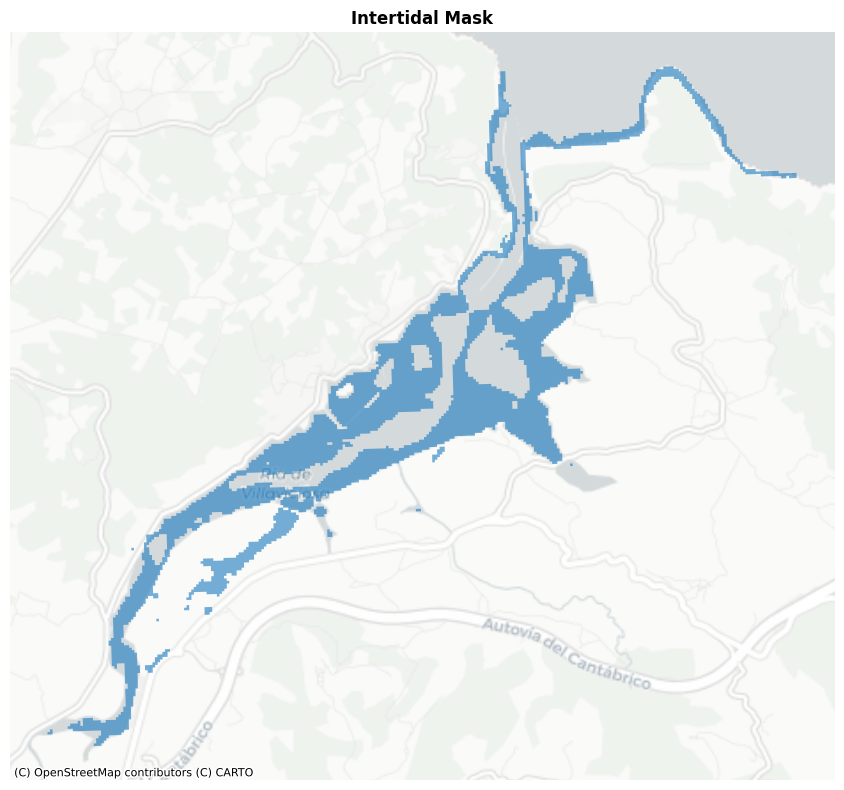

In [9]:
#-----------------------------
#LOAD WATER FREQUENCY RASTER
#Reproject to ref_ds grid so intertidal_mask always matches scl_arr shape
#-----------------------------
_ny, _nx = ref_ds.sizes["y"], ref_ds.sizes["x"]
_dst_transform = ref_ds.rio.transform()
_dst_crs = ref_ds.rio.crs

with rasterio.open("outputs/water_frequency.tif") as src:
	freq = np.empty((_ny, _nx), dtype=np.float32)

	rio_reproject(
		source=rasterio.band(src, 1),
		destination=freq,
		src_transform=src.transform,
		src_crs=src.crs,
		dst_transform=_dst_transform,
		dst_crs=_dst_crs,
		resampling=Resampling.bilinear,
	)

	transform = _dst_transform
	crs = _dst_crs
	meta = src.meta.copy()

meta.update(height=_ny, width=_nx, transform=transform, crs=crs)

#--------------------

# -----------------------------
# CREATE INTERTIDAL MASK
# -----------------------------
intertidal_mask = np.zeros_like(freq, dtype=np.uint8)
intertidal_mask[(freq >= 0.1) & (freq <= 0.95)] = 1

# -----------------------------
# SAVE MASK AS GEOTIFF
# -----------------------------
# meta.update(dtype=rasterio.uint8, count=1, compress="LZW")

# with rasterio.open("outputs/intertidal_mask.tif", "w", **meta) as dst:
#     dst.write(intertidal_mask, 1)

# print("Intertidal mask raster saved")

# -----------------------------
# RASTER → VECTOR POLYGONS
# -----------------------------
geoms = []

for geom, value in shapes(intertidal_mask, transform=transform):
    if value == 1:
        geoms.append(shape(geom))

gdf = gpd.GeoDataFrame(geometry=geoms, crs=crs)

# -----------------------------
# DISSOLVE INTO SINGLE MULTIPART POLYGON
# -----------------------------
gdf = gdf.dissolve()
gdf = gdf.reset_index(drop=True)

# -----------------------------
# SAVE VECTOR FILE
# -----------------------------
# gdf.to_file("outputs/intertidal_mask.gpkg", driver="GPKG")

# print("Intertidal vector saved: outputs/intertidal_mask.gpkg")

# -----------------------------
# PLOT ON CONTEXTILY BASEMAP
# -----------------------------
gdf_wm = gdf.to_crs(crs_web_mercator)

fig, ax = plt.subplots(figsize=(10, 8))
gdf_wm.plot(ax=ax, color="#1a7abf", alpha=0.6, zorder=2)
ctx.add_basemap(ax, crs=crs_web_mercator, source=ctx.providers.CartoDB.Positron, zoom=13, zorder=1)
ax.set_title("Intertidal Mask", fontsize=12, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()


## NDVI Trends in the Intertidal Zone

### What is NDVI and how does it work?

The **Normalised Difference Vegetation Index (NDVI)** exploits the fact that living green vegetation absorbs strongly in the red wavelength (chlorophyll absorption peak, ~665 nm) while reflecting strongly in the near-infrared (cell-structure scattering, ~850 nm). The contrast between these two bands is a sensitive proxy for photosynthetic activity and leaf area:

$$\text{NDVI} = \frac{\rho_{\text{NIR}} - \rho_{\text{Red}}}{\rho_{\text{NIR}} + \rho_{\text{Red}}}$$

where $\rho$ denotes surface reflectance. NDVI ranges from −1 to +1:

| NDVI range | Typical interpretation |
|---|---|
| < 0 | Water, ice, bare rock |
| 0 – 0.1 | Bare soil, sand, senescent vegetation |
| 0.1 – 0.2 | Sparse or stressed vegetation |
| **> 0.2** | **Actively growing vegetation** (our threshold) |
| > 0.5 | Dense green vegetation |

In the Sentinel-2 L2A product we compute NDVI from **B04** (Red, 665 nm, 10 m) and **B08** (NIR broad, 842 nm, 10 m).

### The tidal confounding problem — and how we solve it

A naïve approach would count the absolute number of vegetated pixels per scene. However, high-tide acquisitions show fewer intertidal pixels (most are submerged) while low-tide scenes show more — creating a spurious tide-driven oscillation in the vegetation signal that has nothing to do with actual vegetation change.

We remove this confounding effect by **normalising by the number of *exposed* intertidal pixels** in each scene, not by the total intertidal area:

$$\text{vegetated fraction} = \frac{\text{intertidal pixels with NDVI} > 0.2 \text{ and SCL} \in \{4, 5\}}{\text{all intertidal pixels with SCL} \in \{4, 5\}}$$

This is equivalent to asking: *"Of the intertidal habitat that was actually accessible for vegetation this overpass, what fraction was green?"* — a tide-independent quantity that reflects true ecological change.

### Cloud filtering at pixel level

After the coarse catalogue-level cloud filter (`eo:cloud_cover < 80 %`), we apply a fine-grained spatial filter: if more than 10 % of the intertidal zone is flagged as cloud (SCL 8, 9, or 10) in a given scene, the entire acquisition is discarded. This prevents cloud shadows — which can mimic low NDVI — from contaminating the time series.


Reference pixel size: 20 m  →  pixel area: 400 m²
Cloud filter: skip scenes where >10% of intertidal pixels are cloudy

  SKIP 2025-05-03 — 100% of intertidal pixels cloudy
  SKIP 2025-05-05 — 50% of intertidal pixels cloudy
  SKIP 2025-05-05 — 94% of intertidal pixels cloudy
  2025-05-08  |  cloud  9.2%  |  exposed  672 px  |  NDVI>0.20:  250 px  =   37.2%  (10.00 ha)
  SKIP 2025-05-10 — 99% of intertidal pixels cloudy
  SKIP 2025-05-13 — 67% of intertidal pixels cloudy
  2025-05-13  |  cloud  1.3%  |  exposed 3825 px  |  NDVI>0.20: 2772 px  =   72.5%  (110.88 ha)
  SKIP 2025-05-18 — 16% of intertidal pixels cloudy
  2025-05-18  |  cloud  9.0%  |  exposed 4145 px  |  NDVI>0.20: 3176 px  =   76.6%  (127.04 ha)
  SKIP 2025-05-22 — 100% of intertidal pixels cloudy
  2025-05-23  |  cloud  0.2%  |  exposed  782 px  |  NDVI>0.20:  172 px  =   22.0%  (6.88 ha)
  2025-05-23  |  cloud  0.0%  |  exposed  870 px  |  NDVI>0.20:  195 px  =   22.4%  (7.80 ha)
  SKIP 2025-05-25 — 48% of intertidal p

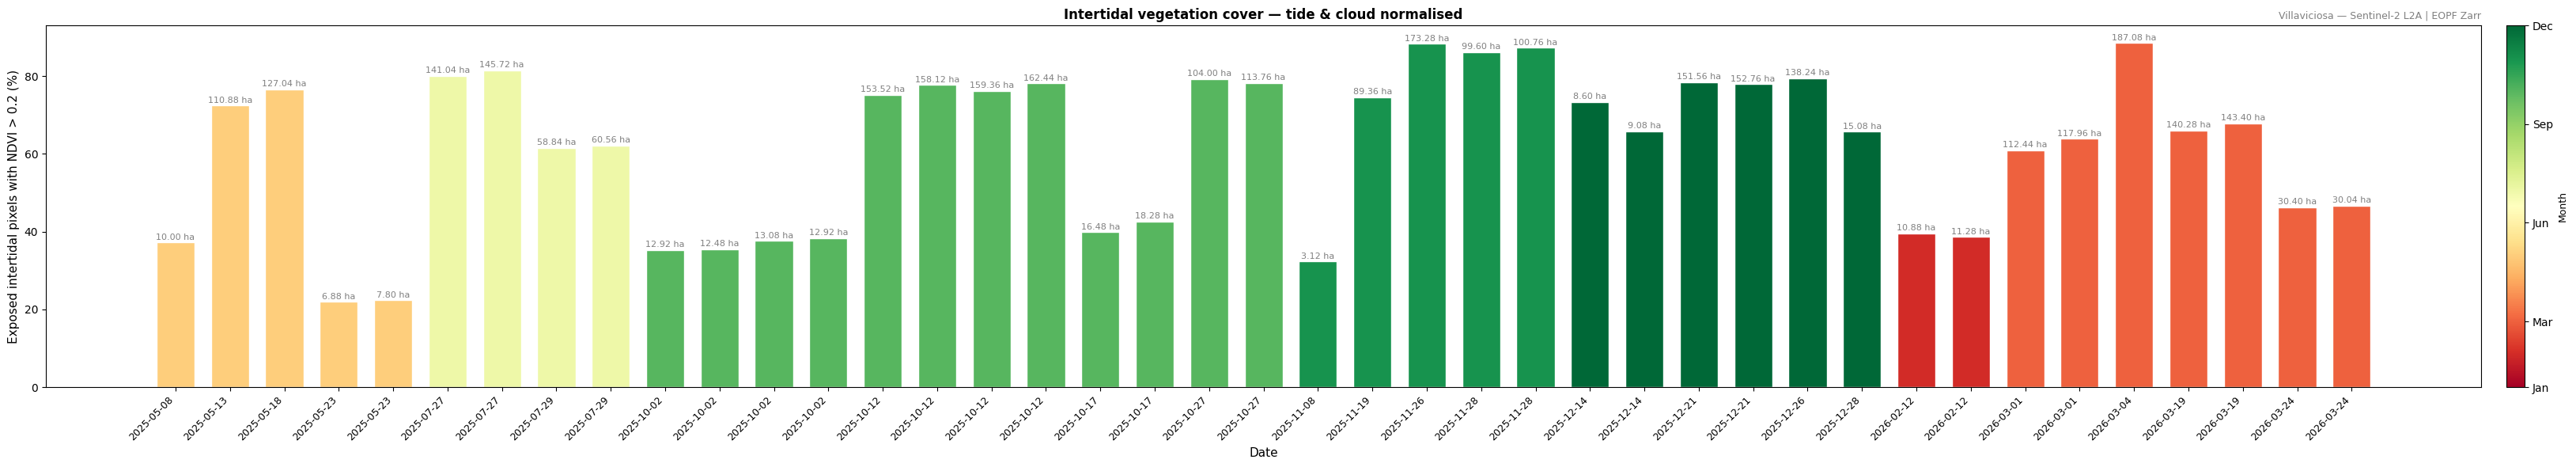

In [10]:
# -----------------------------------------------------------------------
# PARAMETERS
# -----------------------------------------------------------------------
CLOUD_SCL        = {8, 9, 10}   # SCL classes: medium cloud, high cloud, thin cirrus
CLOUD_MAX_FRAC   = 0.10          # skip scene if >10 % of intertidal pixels are cloudy
NDVI_THRESHOLD   = 0.20          # minimum NDVI to consider a pixel vegetated

# -----------------------------------------------------------------------
# Pixel area from the reference SCL grid
# -----------------------------------------------------------------------
res = abs(float(ref_ds.rio.resolution()[0]))
pixel_area_m2 = res ** 2

print(f"Reference pixel size: {res:.0f} m  →  pixel area: {pixel_area_m2:.0f} m²")
print(f"Cloud filter: skip scenes where >{CLOUD_MAX_FRAC*100:.0f}% of intertidal pixels are cloudy\n")

# -----------------------------------------------------------------------
# Main loop
# -----------------------------------------------------------------------
records = []

for item, ds in zip(included_items, datasets):

    date = item.datetime
    date_str = date.strftime("%Y-%m-%d")

    # --- Check required bands ---
    # if "scl" not in ds or "b04" not in ds or "b08" not in ds:
    #     print(f"  SKIP {date_str} — missing scl, b04 or b08")
    #     continue

    # ---- Reproject SCL to reference grid --------------------------------
    scl = ds["scl"]
    if scl.rio.crs is None:
        scl = scl.rio.write_crs(target_crs, inplace=True)

    scl_arr = scl.rio.reproject_match(
        ref_ds, resampling=rasterio.enums.Resampling.nearest
    ).values

    # ---- Cloud check over the intertidal zone ---------------------------
    intertidal_pixels = intertidal_mask == 1
    n_intertidal = int(intertidal_pixels.sum())

    cloud_mask = np.isin(scl_arr, list(CLOUD_SCL))
    n_cloud_intertidal = int((cloud_mask & intertidal_pixels).sum())
    cloud_frac = n_cloud_intertidal / n_intertidal if n_intertidal > 0 else 1.0

    if cloud_frac > CLOUD_MAX_FRAC:
        print(f"  SKIP {date_str} — {cloud_frac*100:.0f}% of intertidal pixels cloudy")
        continue

    # ---- Available substrate: exposed, cloud-free intertidal pixels -----
    # SCL 4 = vegetation, SCL 5 = bare soil  (dry & visible, not water, not cloud)
    exposed = np.isin(scl_arr, [4, 5]) & intertidal_pixels
    n_available = int(exposed.sum())

    if n_available == 0:
        print(f"  SKIP {date_str} — no exposed intertidal pixels after cloud mask")
        continue

    # ---- NDVI -----------------------------------------------------------
    red = ds["b04"]
    nir = ds["b8a"]

    if red.rio.crs is None:
        red = red.rio.write_crs(target_crs, inplace=True)
    if nir.rio.crs is None:
        nir = nir.rio.write_crs(target_crs, inplace=True)

    red_arr = red.rio.reproject_match(ref_ds, resampling=rasterio.enums.Resampling.bilinear).values.astype(float)
    nir_arr = nir.rio.reproject_match(ref_ds, resampling=rasterio.enums.Resampling.bilinear).values.astype(float)

    nodata = (red_arr <= 0) | (nir_arr <= 0) | (red_arr >= 65535) | (nir_arr >= 65535)
    denom  = nir_arr + red_arr
    # ndvi   = np.where((denom > 0) & ~nodata, (nir_arr - red_arr) / denom, np.nan)
    ndvi = np.full(nir_arr.shape, np.nan)
    # Divide only where denom is valid
    np.divide((nir_arr - red_arr), denom, out=ndvi, where=(denom > 0) & ~nodata)
    # ---- Count vegetated pixels only within exposed intertidal pixels ---
    # (tide-independent: denominator shrinks on high-tide scenes)
    high_ndvi = (ndvi > NDVI_THRESHOLD) & exposed
    n_high_ndvi   = int(np.sum(high_ndvi))
    pct_vegetated = 100.0 * n_high_ndvi / n_available
    area_ha        = n_high_ndvi * pixel_area_m2 / 10_000

    records.append({
        "date":              date,
        "cloud_pct":         round(cloud_frac * 100, 1),
        "exposed_px":        n_available,
        "high_ndvi_pct":     round(pct_vegetated, 2),
        "high_ndvi_area_ha": round(area_ha, 3),
    })
    print(
        f"  {date_str}  |  cloud {cloud_frac*100:4.1f}%  |  "
        f"exposed {n_available:4d} px  |  "
        f"NDVI>{NDVI_THRESHOLD:.2f}: {n_high_ndvi:4d} px  =  "
        f"{pct_vegetated:5.1f}%  ({area_ha:.2f} ha)"
    )

# -----------------------------------------------------------------------
# DataFrame
# -----------------------------------------------------------------------
df_ndvi = pd.DataFrame(records).sort_values("date").reset_index(drop=True)

print(f"\n{'='*60}")
print(df_ndvi.to_string(index=False))

# -----------------------------------------------------------------------
# Plot: time (x) vs % vegetated intertidal (y)
# -----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(max(6, len(df_ndvi) * 0.8), 6))

months = df_ndvi["date"].dt.month
cmap   = plt.cm.RdYlGn
norm   = plt.Normalize(vmin=1, vmax=12)
colors = cmap(norm(months))

x_pos = range(len(df_ndvi))
bars  = ax.bar(x_pos, df_ndvi["high_ndvi_pct"], color=colors, edgecolor="white", width=0.7)

# Annotate each bar with the absolute area for reference
for bar, area in zip(bars, df_ndvi["high_ndvi_area_ha"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
        f"{area:.2f} ha", va="bottom", ha="center", fontsize=8, color="grey"
    )

ax.set_xticks(list(x_pos))
ax.set_xticklabels(df_ndvi["date"].dt.strftime("%Y-%m-%d"), rotation=45, ha="right", fontsize=9)
ax.set_ylabel(f"Exposed intertidal pixels with NDVI > {NDVI_THRESHOLD} (%)", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.set_title(
    "Intertidal vegetation cover — tide & cloud normalised",
    fontsize=12, fontweight="bold"
)
ax.set_title("Villaviciosa — Sentinel-2 L2A | EOPF Zarr", fontsize=9, color="grey", loc="right")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation="vertical", fraction=0.02, pad=0.01)
cbar.set_label("Month", fontsize=9)
cbar.set_ticks([1, 3, 6, 9, 12])
cbar.set_ticklabels(["Jan", "Mar", "Jun", "Sep", "Dec"])

plt.tight_layout()
# plt.savefig("outputs/ndvi_temporal_variability.png", dpi=300, bbox_inches="tight")
plt.show()

# print("Plot saved: outputs/ndvi_temporal_variability.png")


### Seasonal Aggregation

Individual scene results are noisy: a single overpass may have barely exposed intertidal pixels (high tide) or an unusually sparse vegetation cover. Aggregating to **seasons** smooths this noise and reveals the underlying ecological phenology:

| Season | Months | Expected signal |
|---|---|---|
| **Winter** | Dec–Feb | Low biological activity |
| **Spring** | Mar–May | Rapid growth of annual species|
| **Summer** | Jun–Aug | Peak NDVI|
| **Autumn** | Sep–Nov | Senescence begins|

The bar chart annotates each season with both the mean vegetated area (in hectares) and the number of contributing scenes (n). Seasons with few scenes should be interpreted with caution — as the rolling archive deepens, confidence in the seasonal means will improve.


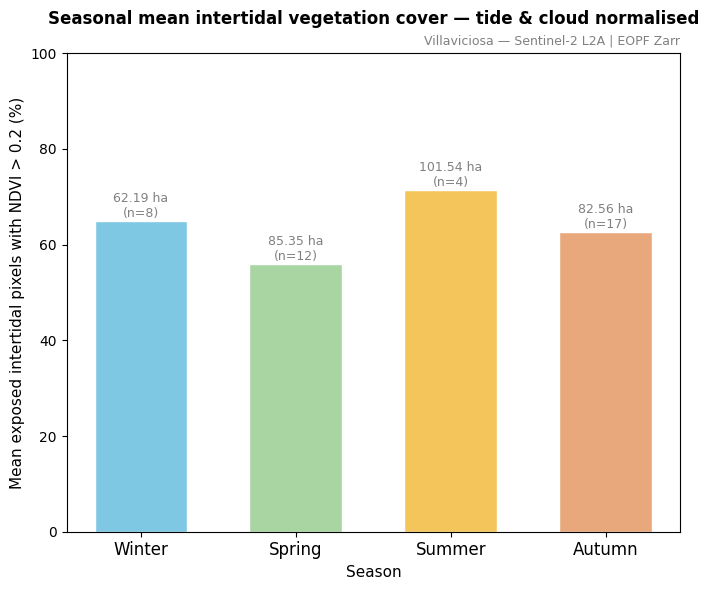

In [11]:

# -----------------------------------------------------------------------
# Seasonal average — Winter / Spring / Summer / Autumn
# -----------------------------------------------------------------------
SEASON_MAP = {12: "Winter",  1: "Winter",  2: "Winter",
               3: "Spring",  4: "Spring",  5: "Spring",
               6: "Summer",  7: "Summer",  8: "Summer",
               9: "Autumn", 10: "Autumn", 11: "Autumn"}
SEASON_ORDER  = ["Winter", "Spring", "Summer", "Autumn"]
SEASON_COLORS = {"Winter": "#7ec8e3", "Spring": "#a8d5a2", "Summer": "#f4c55b", "Autumn": "#e8a87c"}

df_seasonal = (
    df_ndvi
    .assign(season=df_ndvi["date"].dt.month.map(SEASON_MAP))
    .groupby("season", as_index=False)
    .agg(
        high_ndvi_pct    =("high_ndvi_pct",      "mean"),
        high_ndvi_area_ha=("high_ndvi_area_ha",   "mean"),
        n_scenes         =("high_ndvi_pct",       "count"),
    )
)
# Ensure logical season order
df_seasonal["season"] = pd.Categorical(df_seasonal["season"], categories=SEASON_ORDER, ordered=True)
df_seasonal = df_seasonal.sort_values("season").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 6))

bars = ax.bar(
    range(len(df_seasonal)),
    df_seasonal["high_ndvi_pct"],
    color=[SEASON_COLORS[s] for s in df_seasonal["season"]],
    edgecolor="white", width=0.6
)

for bar, row in zip(bars, df_seasonal.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
        f"{row.high_ndvi_area_ha:.2f} ha\n(n={row.n_scenes})",
        va="bottom", ha="center", fontsize=9, color="grey"
    )

ax.set_xticks(range(len(df_seasonal)))
ax.set_ylim(0, 100)
ax.set_xticklabels(df_seasonal["season"], fontsize=12)
ax.set_ylabel(f"Mean exposed intertidal pixels with NDVI > {NDVI_THRESHOLD} (%)", fontsize=11)
ax.set_xlabel("Season", fontsize=11)
ax.set_title(
    "Seasonal mean intertidal vegetation cover — tide & cloud normalised\n",
    fontsize=12, fontweight="bold"
)
ax.set_title("Villaviciosa — Sentinel-2 L2A | EOPF Zarr", fontsize=9, color="grey", loc="right")

plt.tight_layout()
# plt.savefig("outputs/ndvi_seasonal_variability.png", dpi=300, bbox_inches="tight")
plt.show()

# print("Plot saved: outputs/ndvi_seasonal_variability.png")


<hr>

## 💪 Now it is your turn

### Task 1: Explore Your Own Area of Interest
- Update `bbox` and `site` in the Study Area cell; all downstream cells are bbox-driven.
### Task 2: Vegetation Index
- Replace the B04/B08 NDVI formula with EVI, SAVI, or a water-quality index such as CHL-Green.
### Task 3: Temporal Analysis
Update `time_range` in the STAC Search cell to restrict or extend the query.



<hr>

## Conclusion

In this notebook we built a **fully cloud-native intertidal vegetation monitoring workflow** for the Villaviciosa Ramsar estuary using Sentinel-2 L2A data served through the EOPF Zarr Sample Service. The key technical achievements were:

1. **Zero-download analysis** — the entire workflow ran against cloud object storage via the `eopf-zarr` xarray engine. No granule was ever saved to disk before processing.
2. **Scalable data discovery** — `pystac_client` queried the EOPF STAC catalogue to identify relevant tiles without inspecting any imagery upfront.
3. **Multi-temporal tidal analysis** — stacking the Scene Classification Layer across ~dozens of acquisitions automatically delineated the intertidal zone from first principles, with no tidal model or DEM required.
4. **Tide-decoupled vegetation monitoring** — by normalising NDVI-positive pixels against exposed (not total) intertidal area, we removed the tidal confounding effect that would otherwise dominate the time series.
5. **Reproducible and updateable** — because the EOPF rolling archive is always growing, re-running the notebook at any future date will automatically incorporate new Sentinel-2 acquisitions and refine both the intertidal mask and the NDVI trend.

### Ecological findings (preliminary)

> The following interpretations are preliminary and will strengthen as the archive grows beyond ~1 year.

- The water-frequency map clearly distinguishes the main estuarine channel (permanently submerged) from the flanking mudflats and saltmarsh (intermittently inundated).
- NDVI values above 0.2 on exposed intertidal pixels indicate the presence of actively photosynthesising vegetation (*Spartina*, macroalgae, seagrass or others).
- Seasonal differences in vegetated fraction, where sufficient scenes exist, are consistent with the expected temperate phenology (late [spring](https://www.youtube.com/watch?v=6T0MFCX9SLI) peak, winter minimum).

### Limitations & extensions

| Limitation | Potential improvement |
|---|---|
| Rolling ~1-year archive | Access full historical archive via CDSE or AWS Open Data to extend the time series |
| Single-site | Loop over multiple Ramsar estuaries for a regional monitoring product |
| SCL-based water detection | Replace with a spectral water index (MNDWI, AWEI) computed directly from bands for improved accuracy in turbid estuaries |
| **NDVI cannot distinguish vegetation types** | NDVI responds to any photosynthesising surface — it cannot separate seagrass from macroalgae or other plants. Seagrass is arguably the most ecologically and conservation-critical species in the Villaviciosa intertidal (blue-carbon sink, fish nursery habitat), yet it is spectrally similar to green macroalgae at 10 m. A supervised d **spectral classification model** trained on multi-band reflectance would enable finer-level mapping and allow seagrass cover to be tracked independently of other vegetation types. |
| No uncertainty quantification | Incorporate field data to derive confidence intervals |


<hr>

## What's next?

This resource is constantly updated! Stay Tuned for new chapters 🛰️ !

*This notebook was developed as a contribution to the [EOPF Zarr Community Notebook Competition](https://github.com/eopf-toolkit/community-notebook-competition).*
